## Import Libraries

In [2]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os, sys
from IPython.display import Image

project_root = Path.cwd().parent.parent
sys.path.append(str(project_root))
os.chdir(project_root)

from fmu2ml.analysis.input_output_relations.analyzers import DirectEffectAnalyzer, DataGenerator
from fmu2ml.analysis.input_output_relations.visualizers import *
from raps.config import ConfigManager

sns.set_style("whitegrid")
%matplotlib inline


## Define Parameters

In [3]:
SYSTEM_NAME = 'marconi100'
config = ConfigManager(system_name=SYSTEM_NAME).get_config()


In [4]:
OUTPUT_DIR = f'../results/{SYSTEM_NAME}/data_analysis/direct_effect_analysis'
os.makedirs(OUTPUT_DIR, exist_ok=True)


SAMPLES_PER_HOUR = 60
TOTAL_TIMESTEPS = 7200

# Input ranges
INPUT_RANGES = {
    'Q_flow': (12.0, 40.0),    # kW
    'T_Air': (288.15, 308.15),   # K
    'T_ext': (283.15, 313.15)    # K
}

# Parallel settings
N_WORKERS = 48
THREADS_PER_WORKER = 1
MEMORY_LIMIT = '64GB'

print(f"System: {SYSTEM_NAME}")
print(f"Workers: {N_WORKERS}")
print(f"Total timesteps: {TOTAL_TIMESTEPS}")
print(f"Samples per hour: {SAMPLES_PER_HOUR}")


System: marconi100
Workers: 48
Total timesteps: 7200
Samples per hour: 60


## Load or Generate Data

In [5]:

data_generator = DataGenerator(
    n_workers=N_WORKERS,
    
    **config
)

analyzer = DirectEffectAnalyzer(
    n_workers=N_WORKERS,
    threads_per_worker=THREADS_PER_WORKER,
    memory_limit=MEMORY_LIMIT,
    **config
)

print(f"Number of CDUs: {config.get('NUM_CDUS', 49)}")
print(f"Initialized analyzers")


2026-02-04 11:12:40 - fmu2ml.analysis.input_output_relations.analyzers.data_generator - INFO - DataGenerator initialized for system: marconi100
2026-02-04 11:12:40 - fmu2ml.analysis.input_output_relations.analyzers.data_generator - INFO - Number of CDUs: 49
2026-02-04 11:12:40 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - DirectEffectAnalyzer initialized for system: marconi100
2026-02-04 11:12:40 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Number of CDUs: 49


Number of CDUs: 49
Initialized analyzers


In [9]:
data_file = os.path.join(OUTPUT_DIR, 'sensitivity_data.parquet')
data = None
if os.path.exists(data_file):
    print("Loading simulation data...")
    data = pd.read_parquet(data_file)
else:
    # Generate Simulation Data
    print("Generating simulation data...")
    data = data_generator.generate_sensitivity_data(
        total_timesteps=TOTAL_TIMESTEPS,
        samples_per_hour=SAMPLES_PER_HOUR,
        input_ranges=INPUT_RANGES
    )
    data.to_parquet(data_file)
    print(f"\nSaved to: {data_file}")

print(f"Data shape: {data.shape}")
print(f"\nInput columns: {len([col for col in data.columns if any(pattern in col for pattern in ['Q_flow', 'T_Air', 'T_ext'])])}")
print(f"""Output columns: {len([col for col in data.columns if not any(pattern in col for pattern in ['V_flow_prim_GPM', 'V_flow_sec_GPM', 'W_flow_CDUP_kW',
                                                                                                    'T_prim_s_C', 'T_prim_r_C', 'T_sec_s_C', 'T_sec_r_C',
                                                                                                    'p_prim_s_psig', 'p_prim_r_psig', 'p_sec_s_psig', 'p_sec_r_psig'] )])} outputs""")


Loading simulation data...
Data shape: (7200, 1230)

Input columns: 99
Output columns: 690 outputs


In [7]:
data.head(5).iloc[:,:10]

,simulator[1].datacenter[1].summary.m_flow_prim,simulator[1].datacenter[1].summary.V_flow_prim_GPM,simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.m_flow_prim,simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.V_flow_prim_GPM,simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.m_flow_sec,simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.V_flow_sec_GPM,simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.W_flow_CDUP,simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.W_flow_CDUP_kW,simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_prim_s,simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_prim_s_C
0,272.843505,4330.849285,5.567669,88.375696,20.000009,317.460466,4172.956758,4.172957,311.641289,38.491289
1,272.843478,4330.848853,5.567668,88.375688,20.000001,317.460340,4172.958824,4.172959,311.641340,38.491340
2,272.843449,4330.848394,5.567668,88.375678,19.999995,317.460236,4172.960629,4.172961,311.641392,38.491392
3,272.843430,4330.848098,5.567667,88.375664,19.999989,317.460151,4172.962217,4.172962,311.641442,38.491442
4,272.843438,4330.848221,5.567666,88.375644,19.999985,317.460081,4172.963624,4.172964,311.641491,38.491491


In [9]:
from fmu2ml.visualization import StandardInputOutputVisualizer

viz  = StandardInputOutputVisualizer(data)

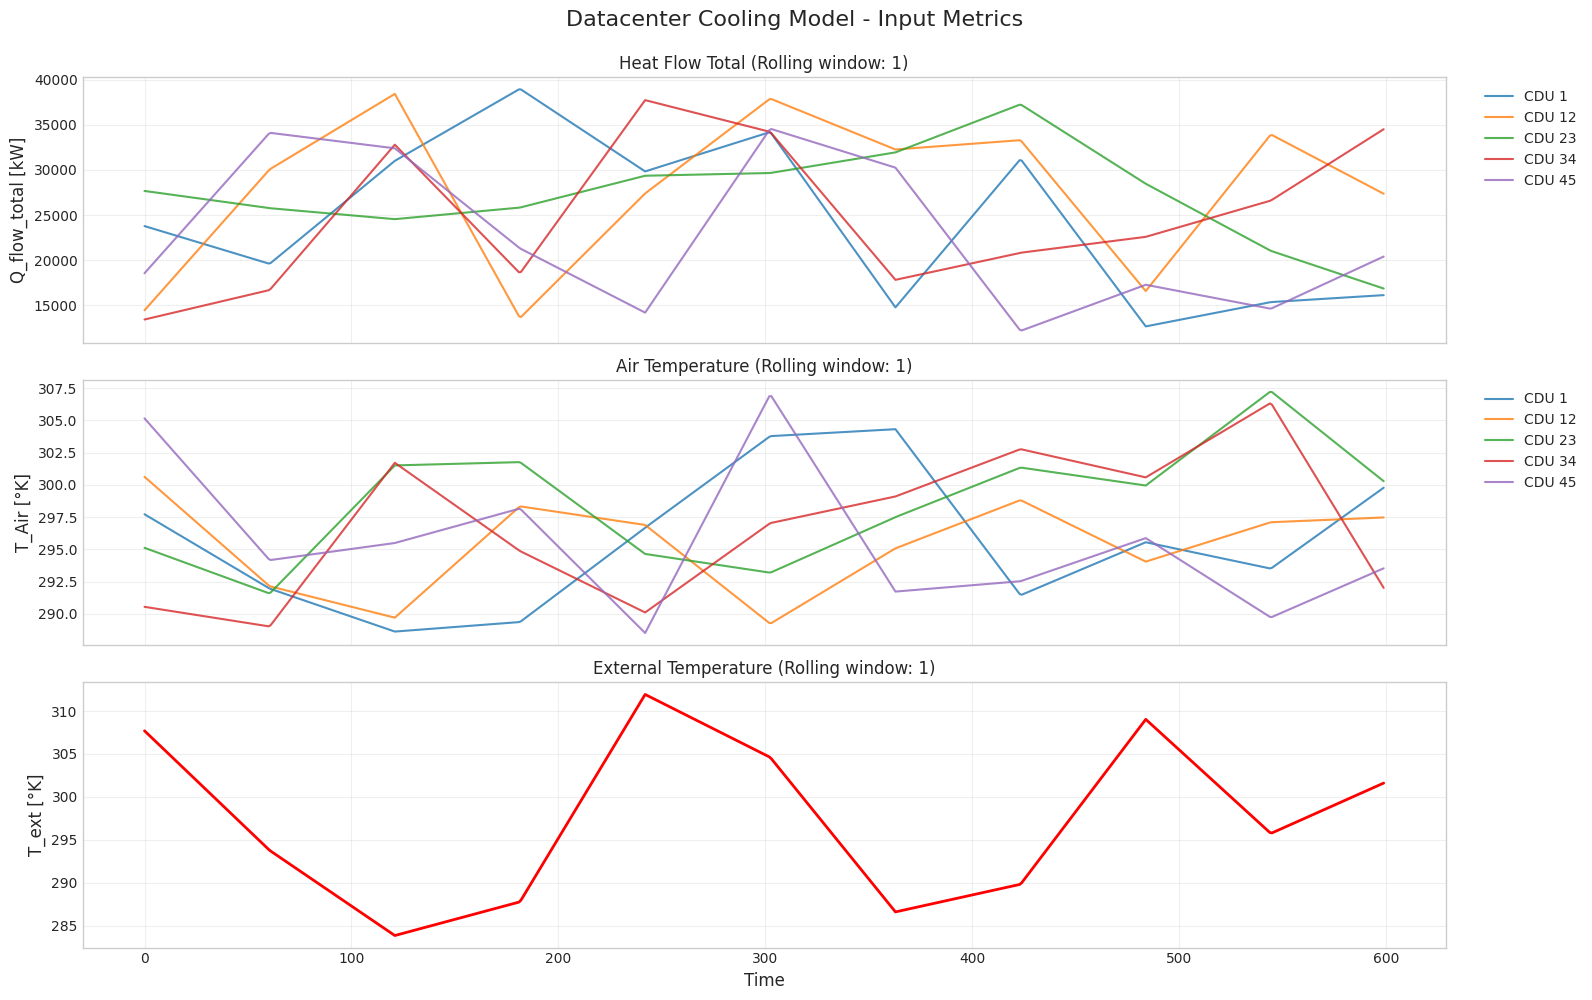

In [10]:
viz.plot_inputs(selected_cdus=[1,12,23,34,45], rolling_windows=1, time_range=[0,600]);

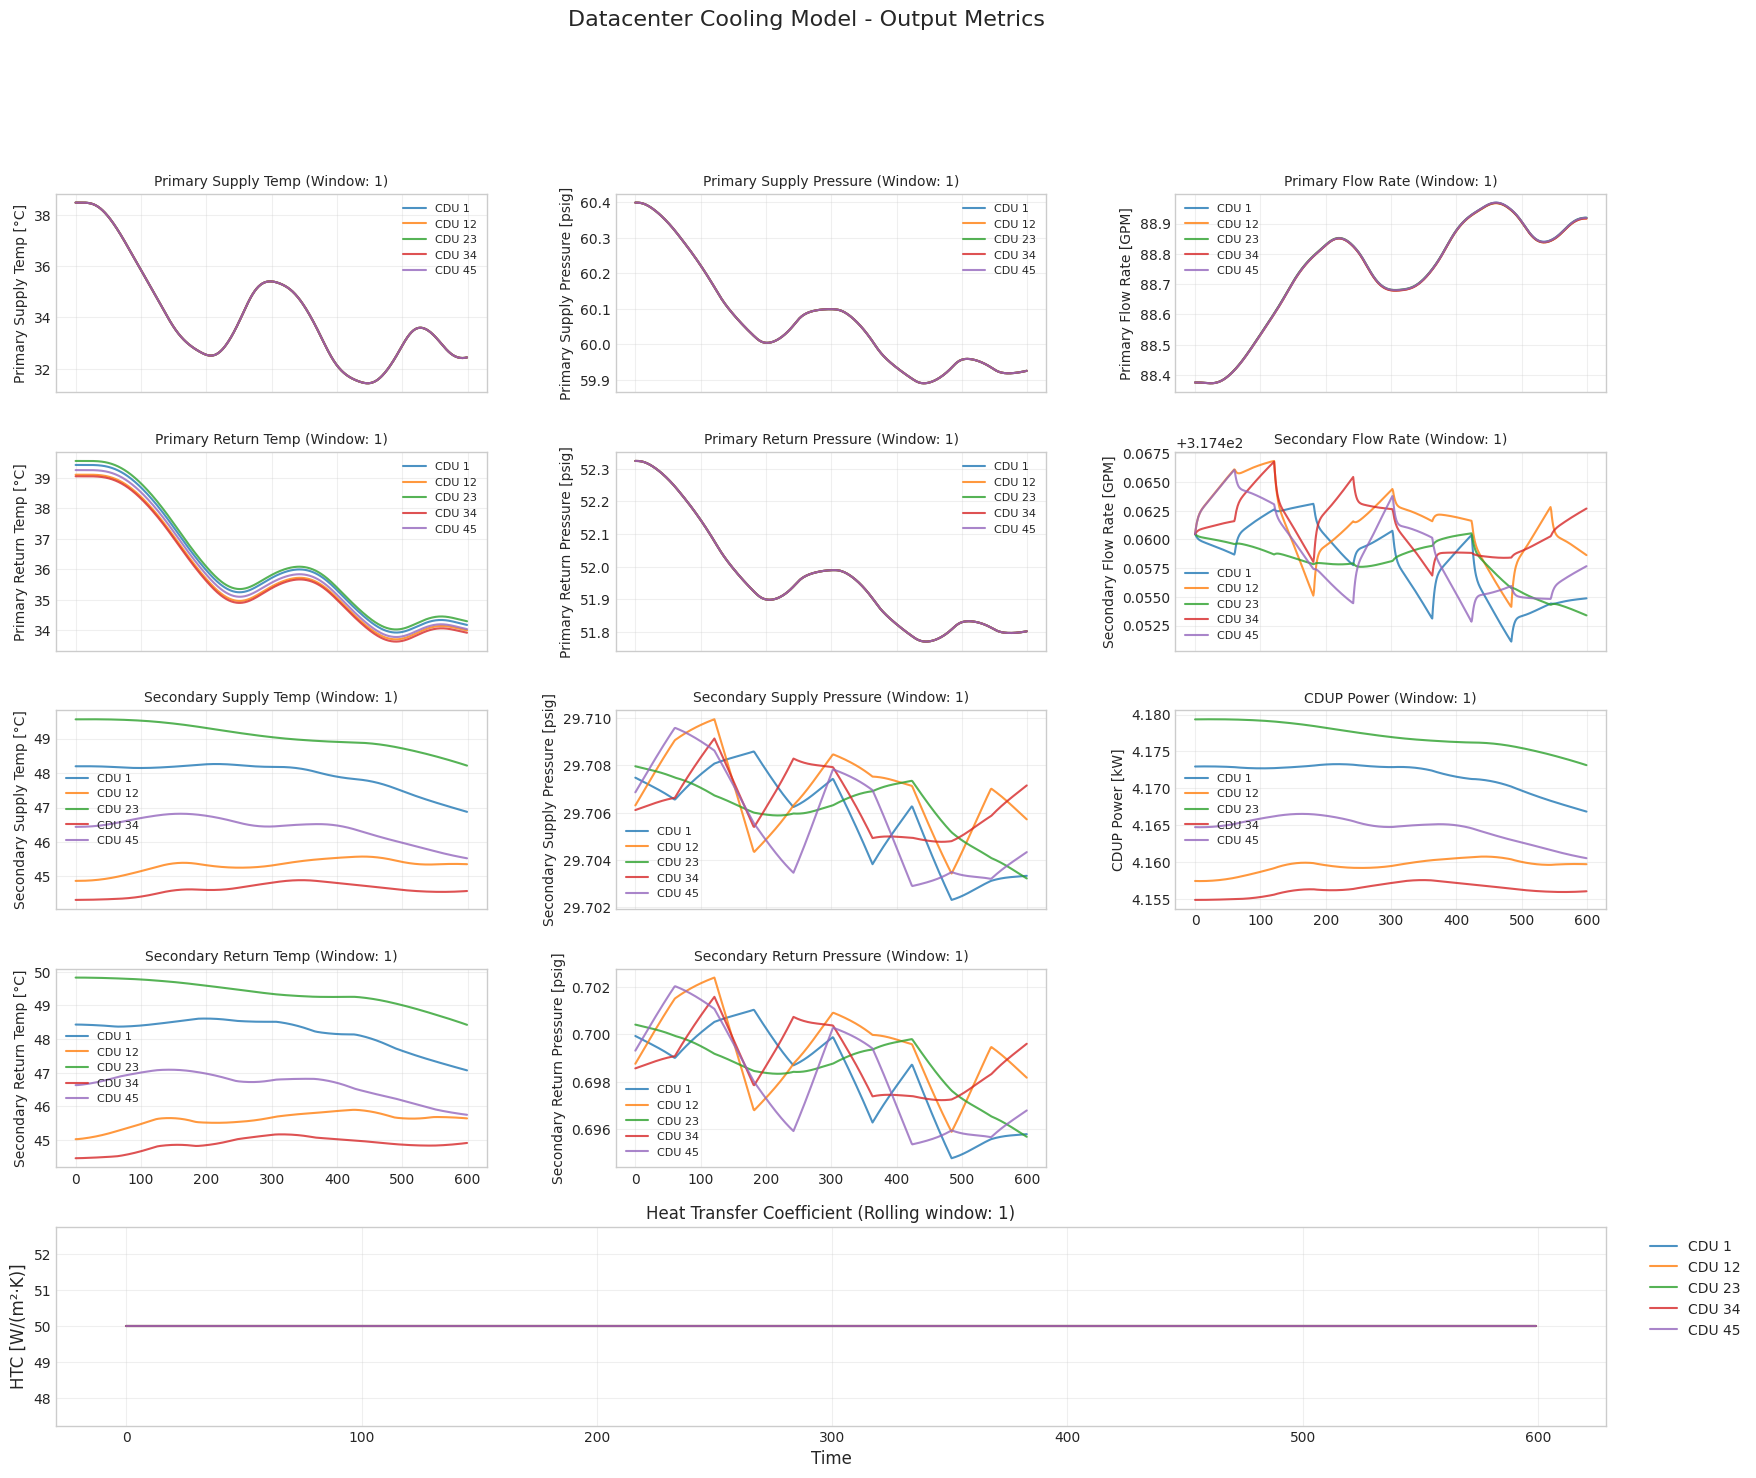

In [11]:
viz.plot_outputs(selected_cdus=[1,12,23,34,45], rolling_windows=1, time_range=[0,600]);

## Data Preparation

In [12]:
# Data Preparation
prepared_data = analyzer.prepare_data(data)


2026-02-03 08:26:22 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Preparing data for direct effect analysis...
2026-02-03 08:26:22 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Data prepared: 3 inputs, 11 outputs


## Univariate Sensitivity Analysis

In [13]:
print("Performing univariate analysis...")
metrics_df = analyzer.analyze_all_pairs(prepared_data)


2026-02-03 08:26:22 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Computing univariate metrics for all input-output pairs using Dask...
2026-02-03 08:26:22 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Initializing Dask cluster for analysis tasks...
2026-02-03 08:26:22 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-02-03 08:26:22 - distributed.scheduler - INFO - State start
2026-02-03 08:26:22 - distributed.scheduler - INFO -   Scheduler at:     tcp://127.0.0.1:46811
2026-02-03 08:26:22 - distributed.scheduler - INFO -   dashboard at:  http://127.0.0.1:42387/status
2026-02-03 08:26:22 - distributed.scheduler - INFO - Registering Worker plugin shuffle
2026-02-03 08:26:22 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:34567'


Performing univariate analysis...


2026-02-03 08:26:22 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:34081'
2026-02-03 08:26:22 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:37093'
2026-02-03 08:26:22 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:41393'
2026-02-03 08:26:22 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:39071'
2026-02-03 08:26:22 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:38901'
2026-02-03 08:26:22 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:37137'
2026-02-03 08:26:22 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:37123'
2026-02-03 08:26:22 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:38041'
2026-02-03 08:26:22 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:40175'
2026-02-03 08:26:22 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:34765'
2026-02-03 08:26:22 - distribu

In [14]:
# Display top correlations
print("\nTop 10 correlations by Mutual Information:")
print(metrics_df.nlargest(10, 'mutual_info')[['input', 'output', 'pearson_r', 'mutual_info', 'r2_score']])



Top 10 correlations by Mutual Information:
     input           output  pearson_r  mutual_info  r2_score
9   Q_flow     p_sec_s_psig   0.806491     0.214075  0.650427
10  Q_flow     p_sec_r_psig   0.806492     0.213974  0.650429
1   Q_flow   V_flow_sec_GPM   0.722786     0.122862  0.522419
29   T_ext    p_prim_s_psig   0.283582     0.095325  0.080419
30   T_ext    p_prim_r_psig   0.138392     0.075687  0.019152
26   T_ext       T_prim_r_C   0.078509     0.073207  0.006164
25   T_ext       T_prim_s_C   0.284683     0.070222  0.081044
22   T_ext  V_flow_prim_GPM  -0.012701     0.066446  0.000161
27   T_ext        T_sec_s_C   0.084042     0.021011  0.007063
24   T_ext   W_flow_CDUP_kW   0.084102     0.020977  0.007073


In [15]:
# Input Importance Rankings
rankings_df = analyzer.rank_input_importance(metrics_df, metric='mutual_info')

print("Input importance by output (Mutual Information):")
for output in analyzer.output_vars[:5]:  # Show first 5 outputs
    output_ranks = rankings_df[rankings_df['output'] == output].head(3)
    print(f"\n{output}:")
    print(output_ranks[['rank', 'input', 'value']].to_string(index=False))


Input importance by output (Mutual Information):

V_flow_prim_GPM:
 rank  input    value
    1  T_ext 0.066446
    2 Q_flow 0.002789
    3  T_Air 0.002380

V_flow_sec_GPM:
 rank  input    value
    1 Q_flow 0.122862
    2  T_ext 0.003663
    3  T_Air 0.001377

W_flow_CDUP_kW:
 rank  input    value
    1  T_ext 0.020977
    2  T_Air 0.002685
    3 Q_flow 0.002658

T_prim_s_C:
 rank  input    value
    1  T_ext 0.070222
    2 Q_flow 0.002040
    3  T_Air 0.001753

T_prim_r_C:
 rank  input    value
    1  T_ext 0.073207
    2  T_Air 0.002380
    3 Q_flow 0.002159


2026-02-03 08:26:34 - fmu2ml.analysis.input_output_relations.visualizers.heatmap_visualizer - INFO - Creating correlation heatmaps in parallel...
2026-02-03 08:26:36 - fmu2ml.analysis.input_output_relations.visualizers.heatmap_visualizer - INFO - Created 4 heatmaps


Heatmaps saved to ../results/marconi100/data_analysis/direct_effect_analysis


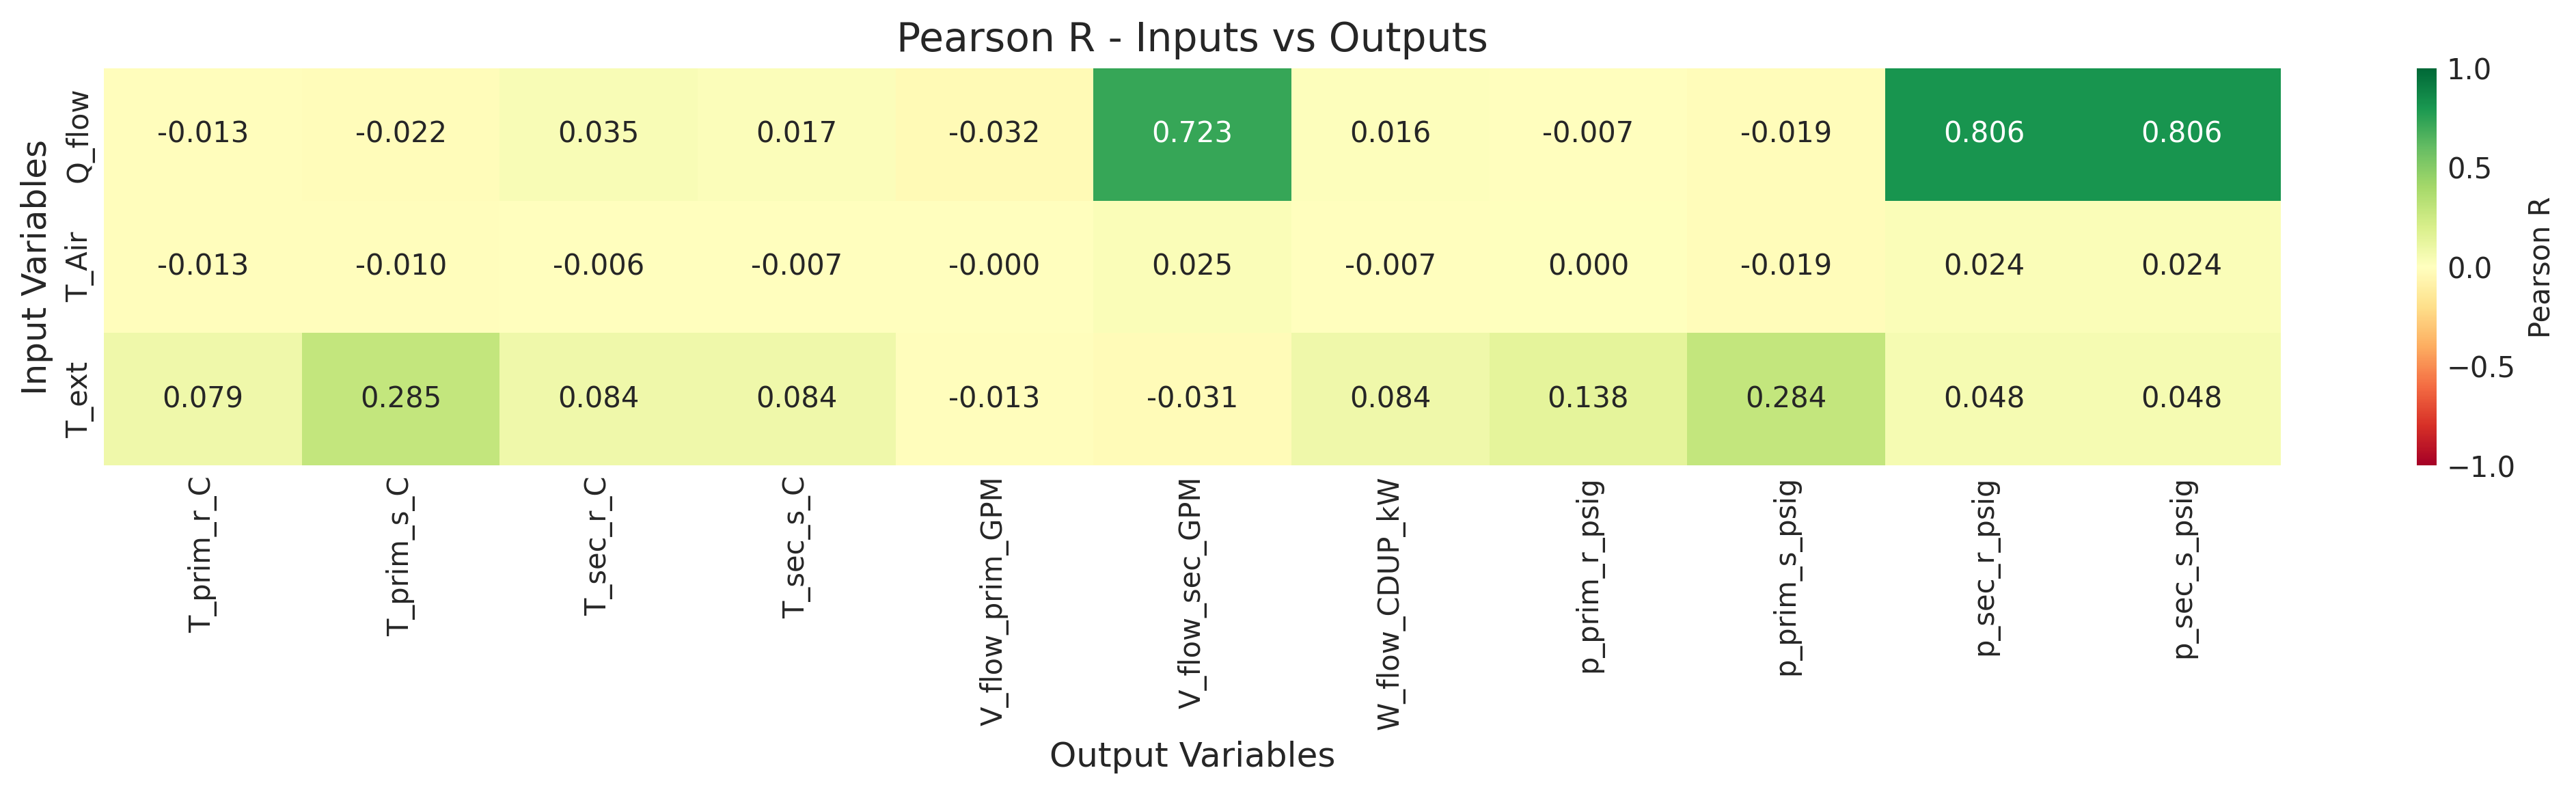

In [16]:
# Correlation Heatmaps
create_correlation_heatmap(metrics_df, OUTPUT_DIR, n_workers=N_WORKERS)
print(f"Heatmaps saved to {OUTPUT_DIR}")

# Display one heatmap inline
from IPython.display import Image
Image(filename=os.path.join(OUTPUT_DIR, 'heatmap_pearson_r.png'))


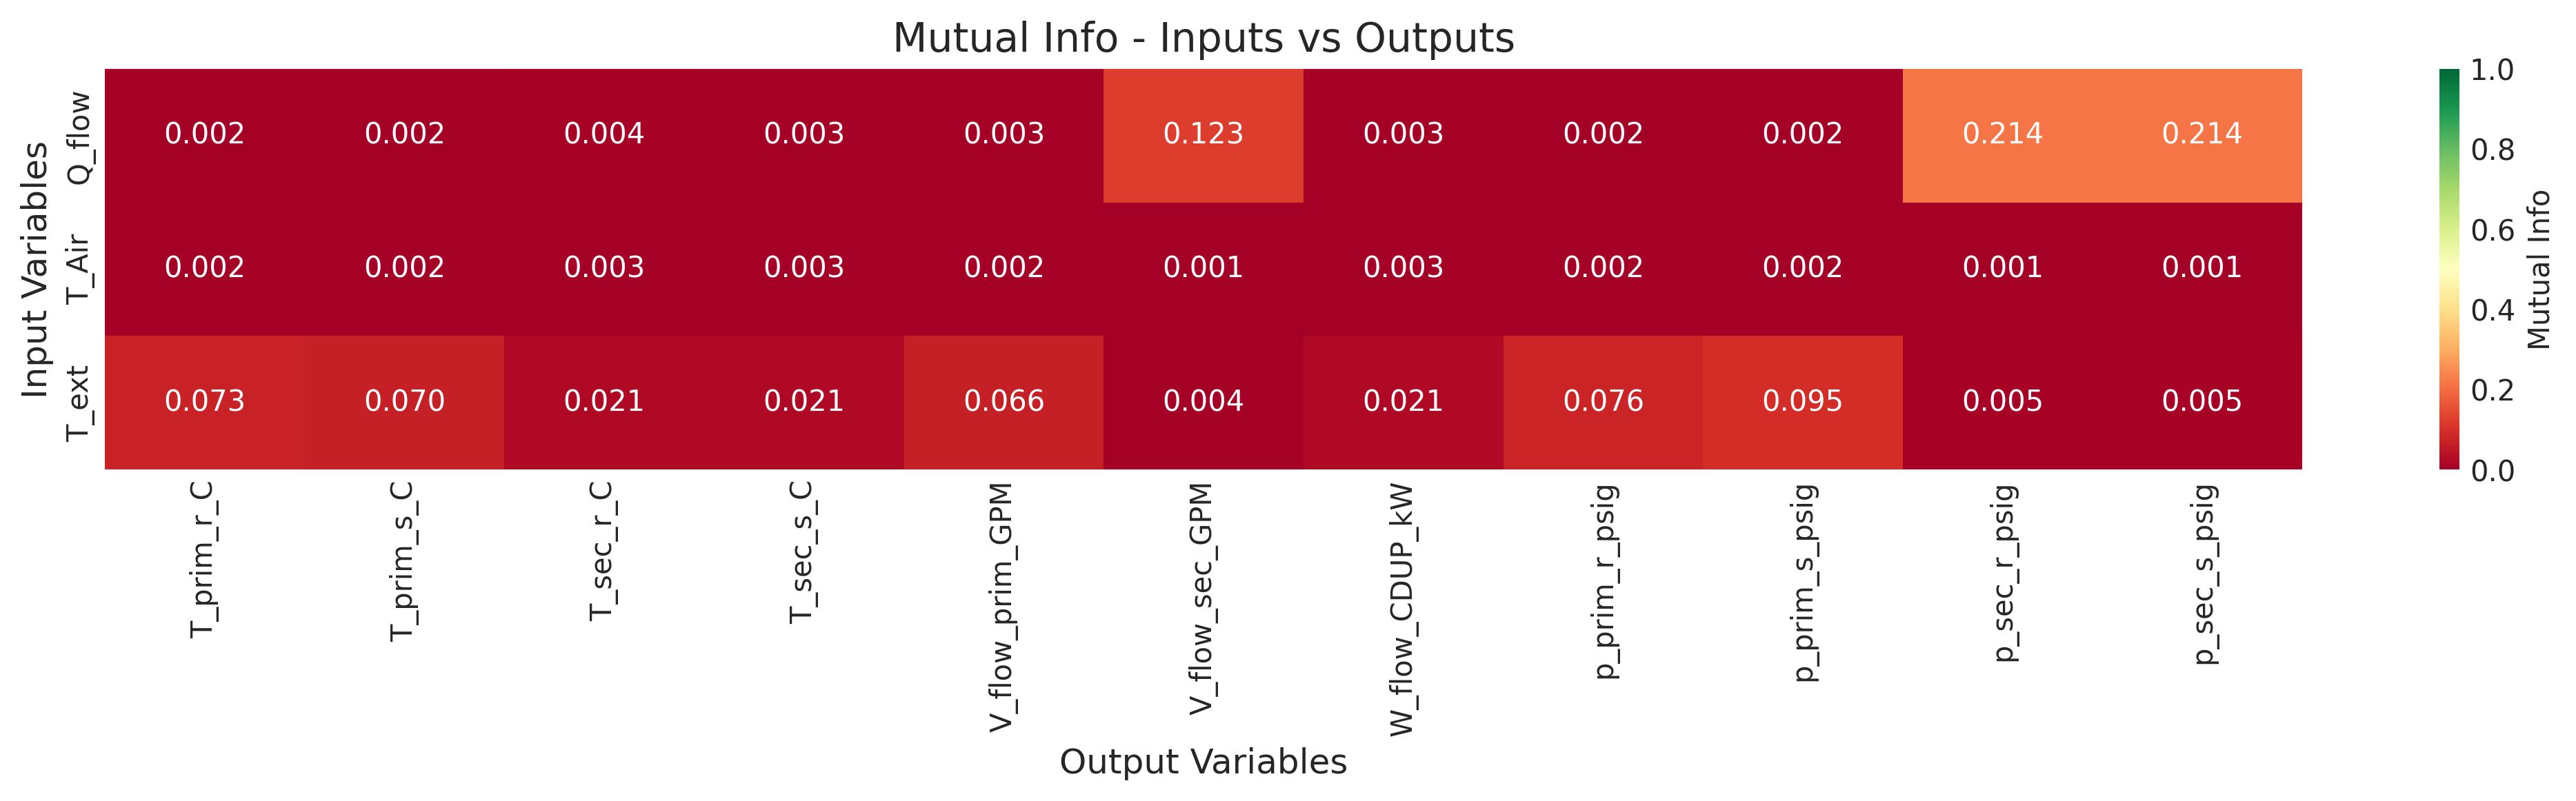

In [17]:
Image(filename=os.path.join(OUTPUT_DIR, 'heatmap_mutual_info.png'))
# heatmap_mutual_info.png   heatmap_r2_score.png     
# heatmap_pearson_r.png     heatmap_spearman_r.png   

## Isolated Effects Analysis

In [22]:

# After running analyze_isolated_effects
isolated_df = analyzer.analyze_isolated_effects(prepared_data, tolerance=0.1)


2026-02-03 08:27:12 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Analyzing isolated input effects (others held at mean)...
2026-02-03 08:27:12 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO -   Q_flow: 1877 samples with others at mean
2026-02-03 08:27:12 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO -   T_Air: 1851 samples with others at mean
2026-02-03 08:27:12 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO -   T_ext: 1573 samples with others at mean


In [23]:

# Create visualizations
create_isolated_effect_heatmap(isolated_df, output_dir=OUTPUT_DIR)
create_isolated_effect_comparison(metrics_df, isolated_df, output_dir=OUTPUT_DIR)
create_isolated_effect_summary(isolated_df, output_dir=OUTPUT_DIR)

2026-02-03 08:27:27 - fmu2ml.analysis.input_output_relations.visualizers.isolated_effect_visualizer - INFO - Creating isolated effect heatmaps...
2026-02-03 08:27:29 - fmu2ml.analysis.input_output_relations.visualizers.isolated_effect_visualizer - INFO - Created isolated effect heatmaps for 3 metrics
2026-02-03 08:27:29 - fmu2ml.analysis.input_output_relations.visualizers.isolated_effect_visualizer - INFO - Creating isolated vs full effect comparison plots...
2026-02-03 08:27:36 - fmu2ml.analysis.input_output_relations.visualizers.isolated_effect_visualizer - INFO - Created comparison plots for 3 inputs
2026-02-03 08:27:36 - fmu2ml.analysis.input_output_relations.visualizers.isolated_effect_visualizer - INFO - Creating isolated effect summary plots...
2026-02-03 08:27:39 - fmu2ml.analysis.input_output_relations.visualizers.isolated_effect_visualizer - INFO - Created isolated effect summary plot


2026-02-03 08:27:58 - fmu2ml.analysis.input_output_relations.visualizers.scatter_visualizer - INFO - Creating scatter plots in parallel...
2026-02-03 08:28:04 - fmu2ml.analysis.input_output_relations.visualizers.scatter_visualizer - INFO - Created scatter plots for 3 inputs


Scatter plots saved to ../results/marconi100/data_analysis/direct_effect_analysis


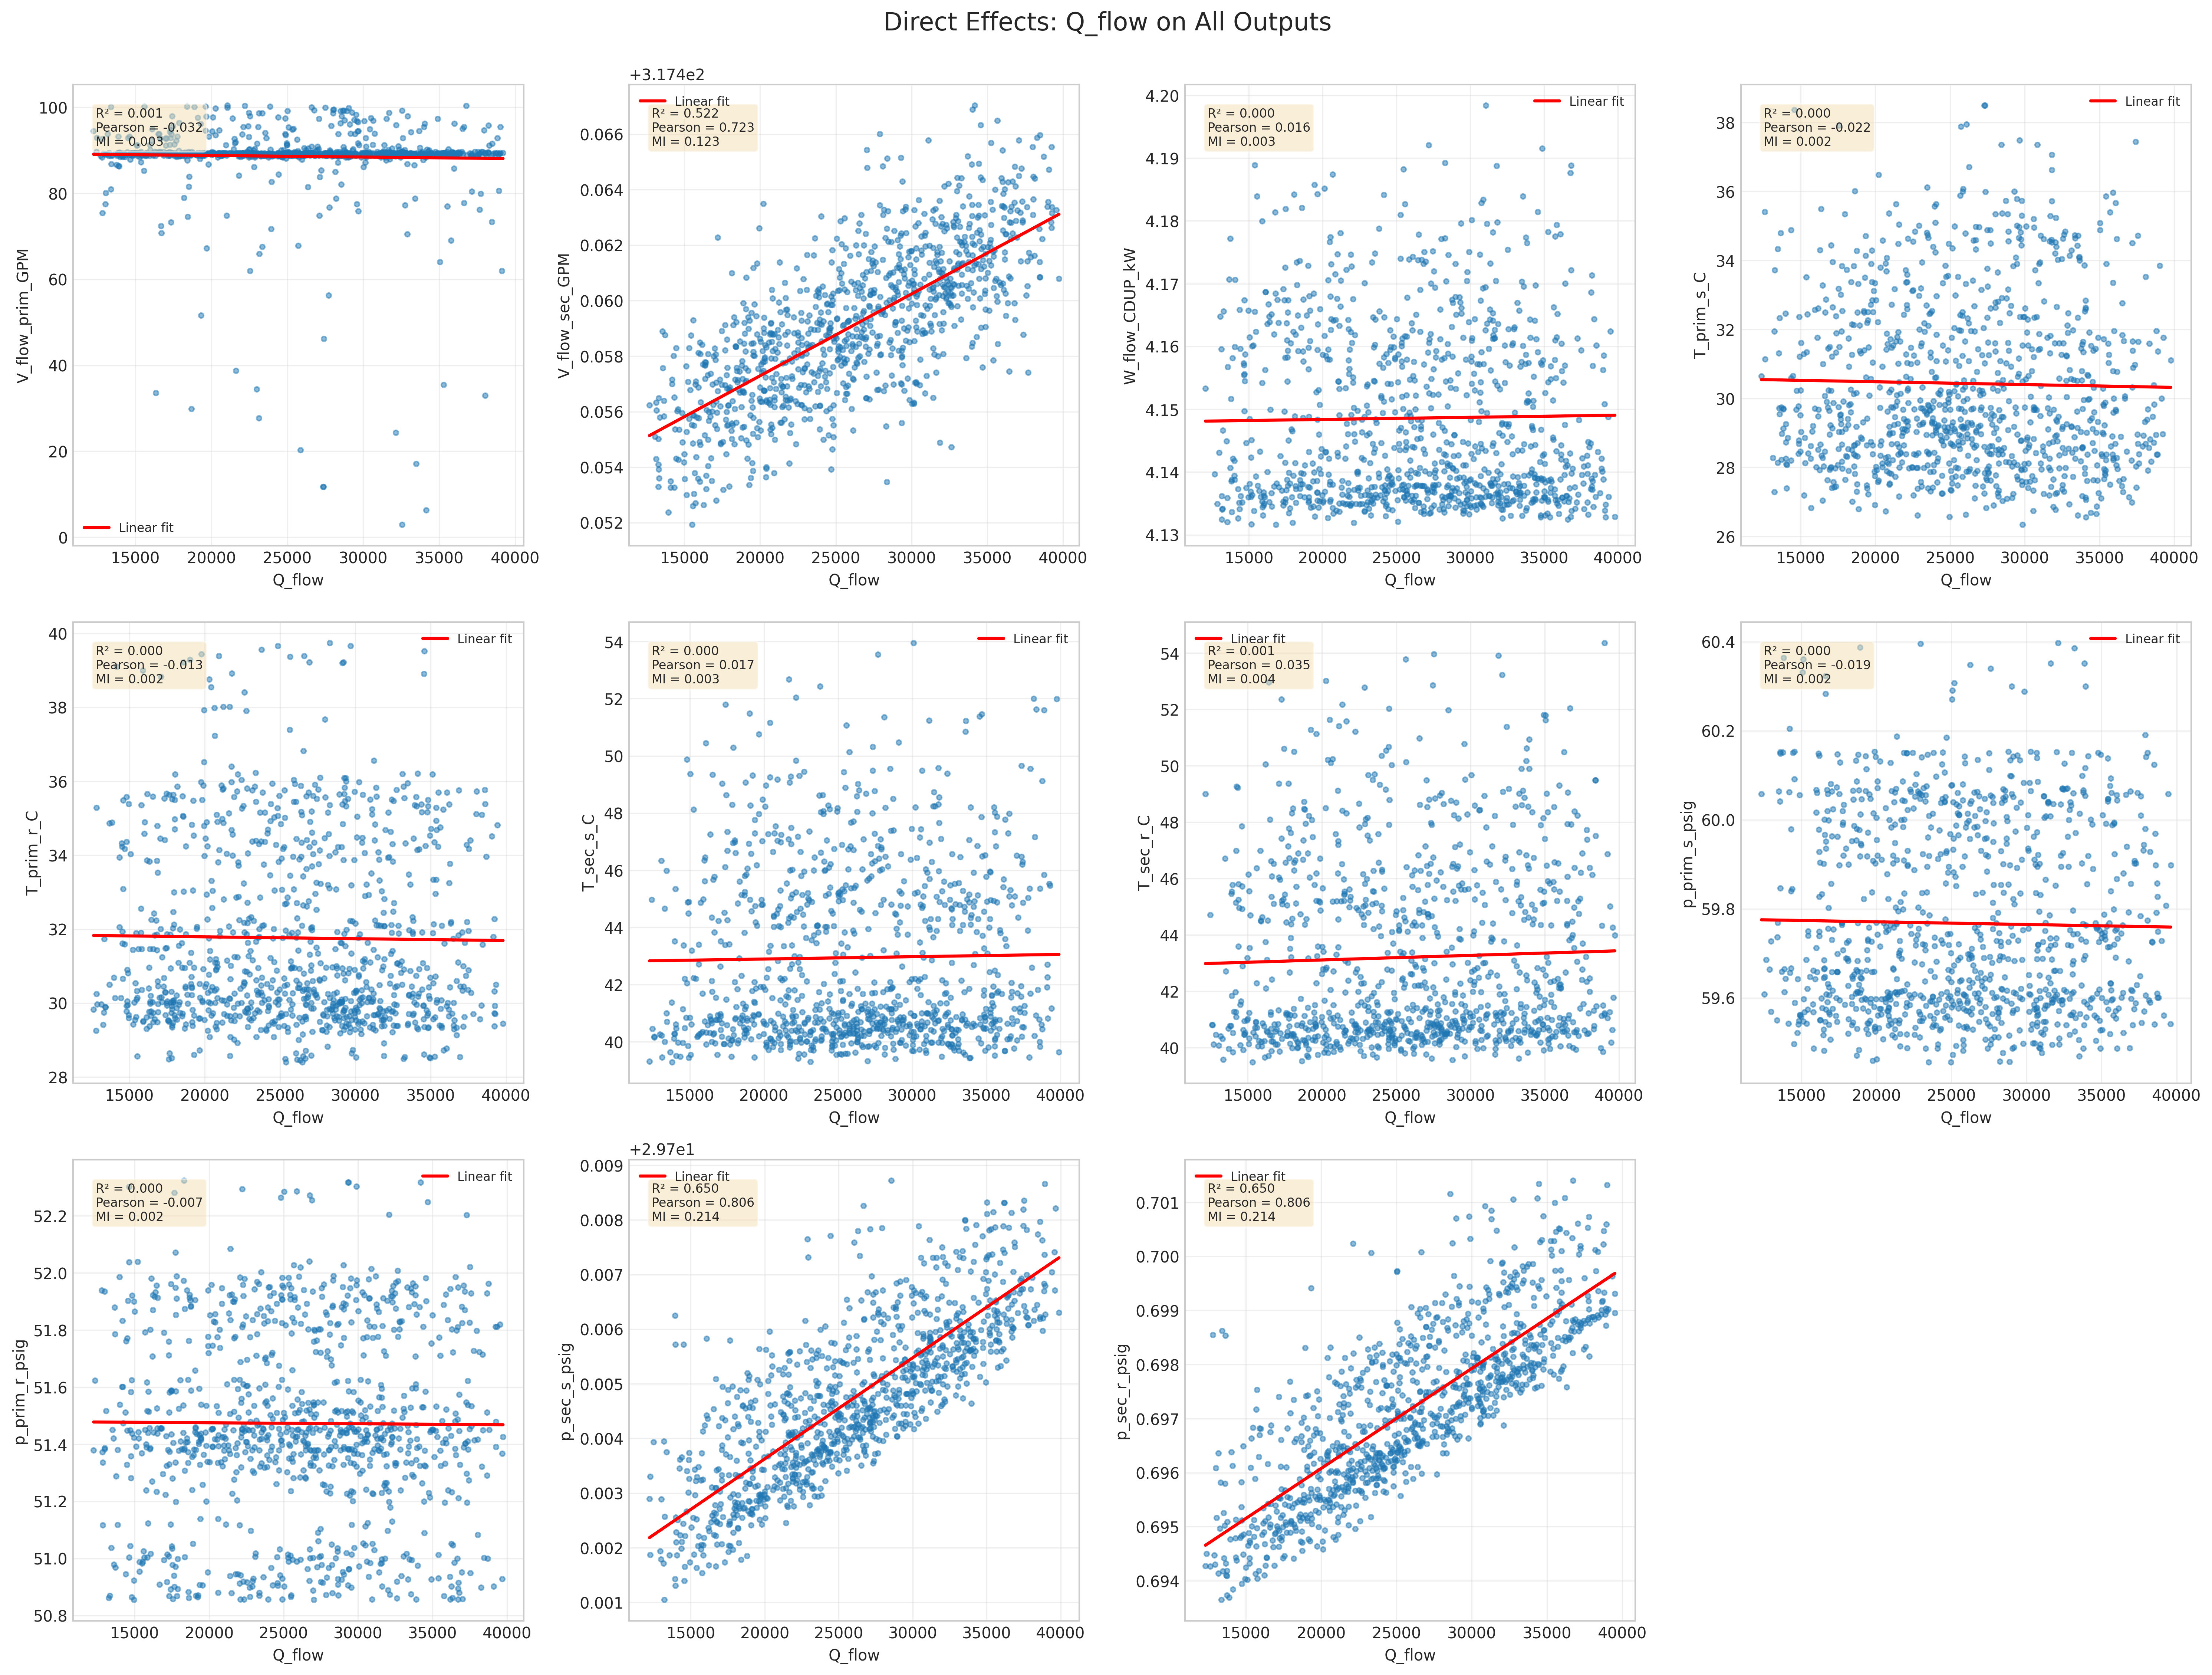

In [24]:
# Scatter Plots for Key Relationships
create_scatter_plots(prepared_data, metrics_df, OUTPUT_DIR, n_workers=N_WORKERS)
print(f"Scatter plots saved to {OUTPUT_DIR}")

# Display example scatter plot
Image(filename=os.path.join(OUTPUT_DIR, 'scatter_plots_Q_flow.png'))
# scatter_plots_T_ext.png   scatter_plots_T_Air.png

2026-02-03 08:28:04 - fmu2ml.analysis.input_output_relations.visualizers.ranking_visualizer - INFO - Creating importance ranking plots...
2026-02-03 08:28:06 - fmu2ml.analysis.input_output_relations.visualizers.ranking_visualizer - INFO - Saved importance ranking plots to ../results/marconi100/data_analysis/direct_effect_analysis


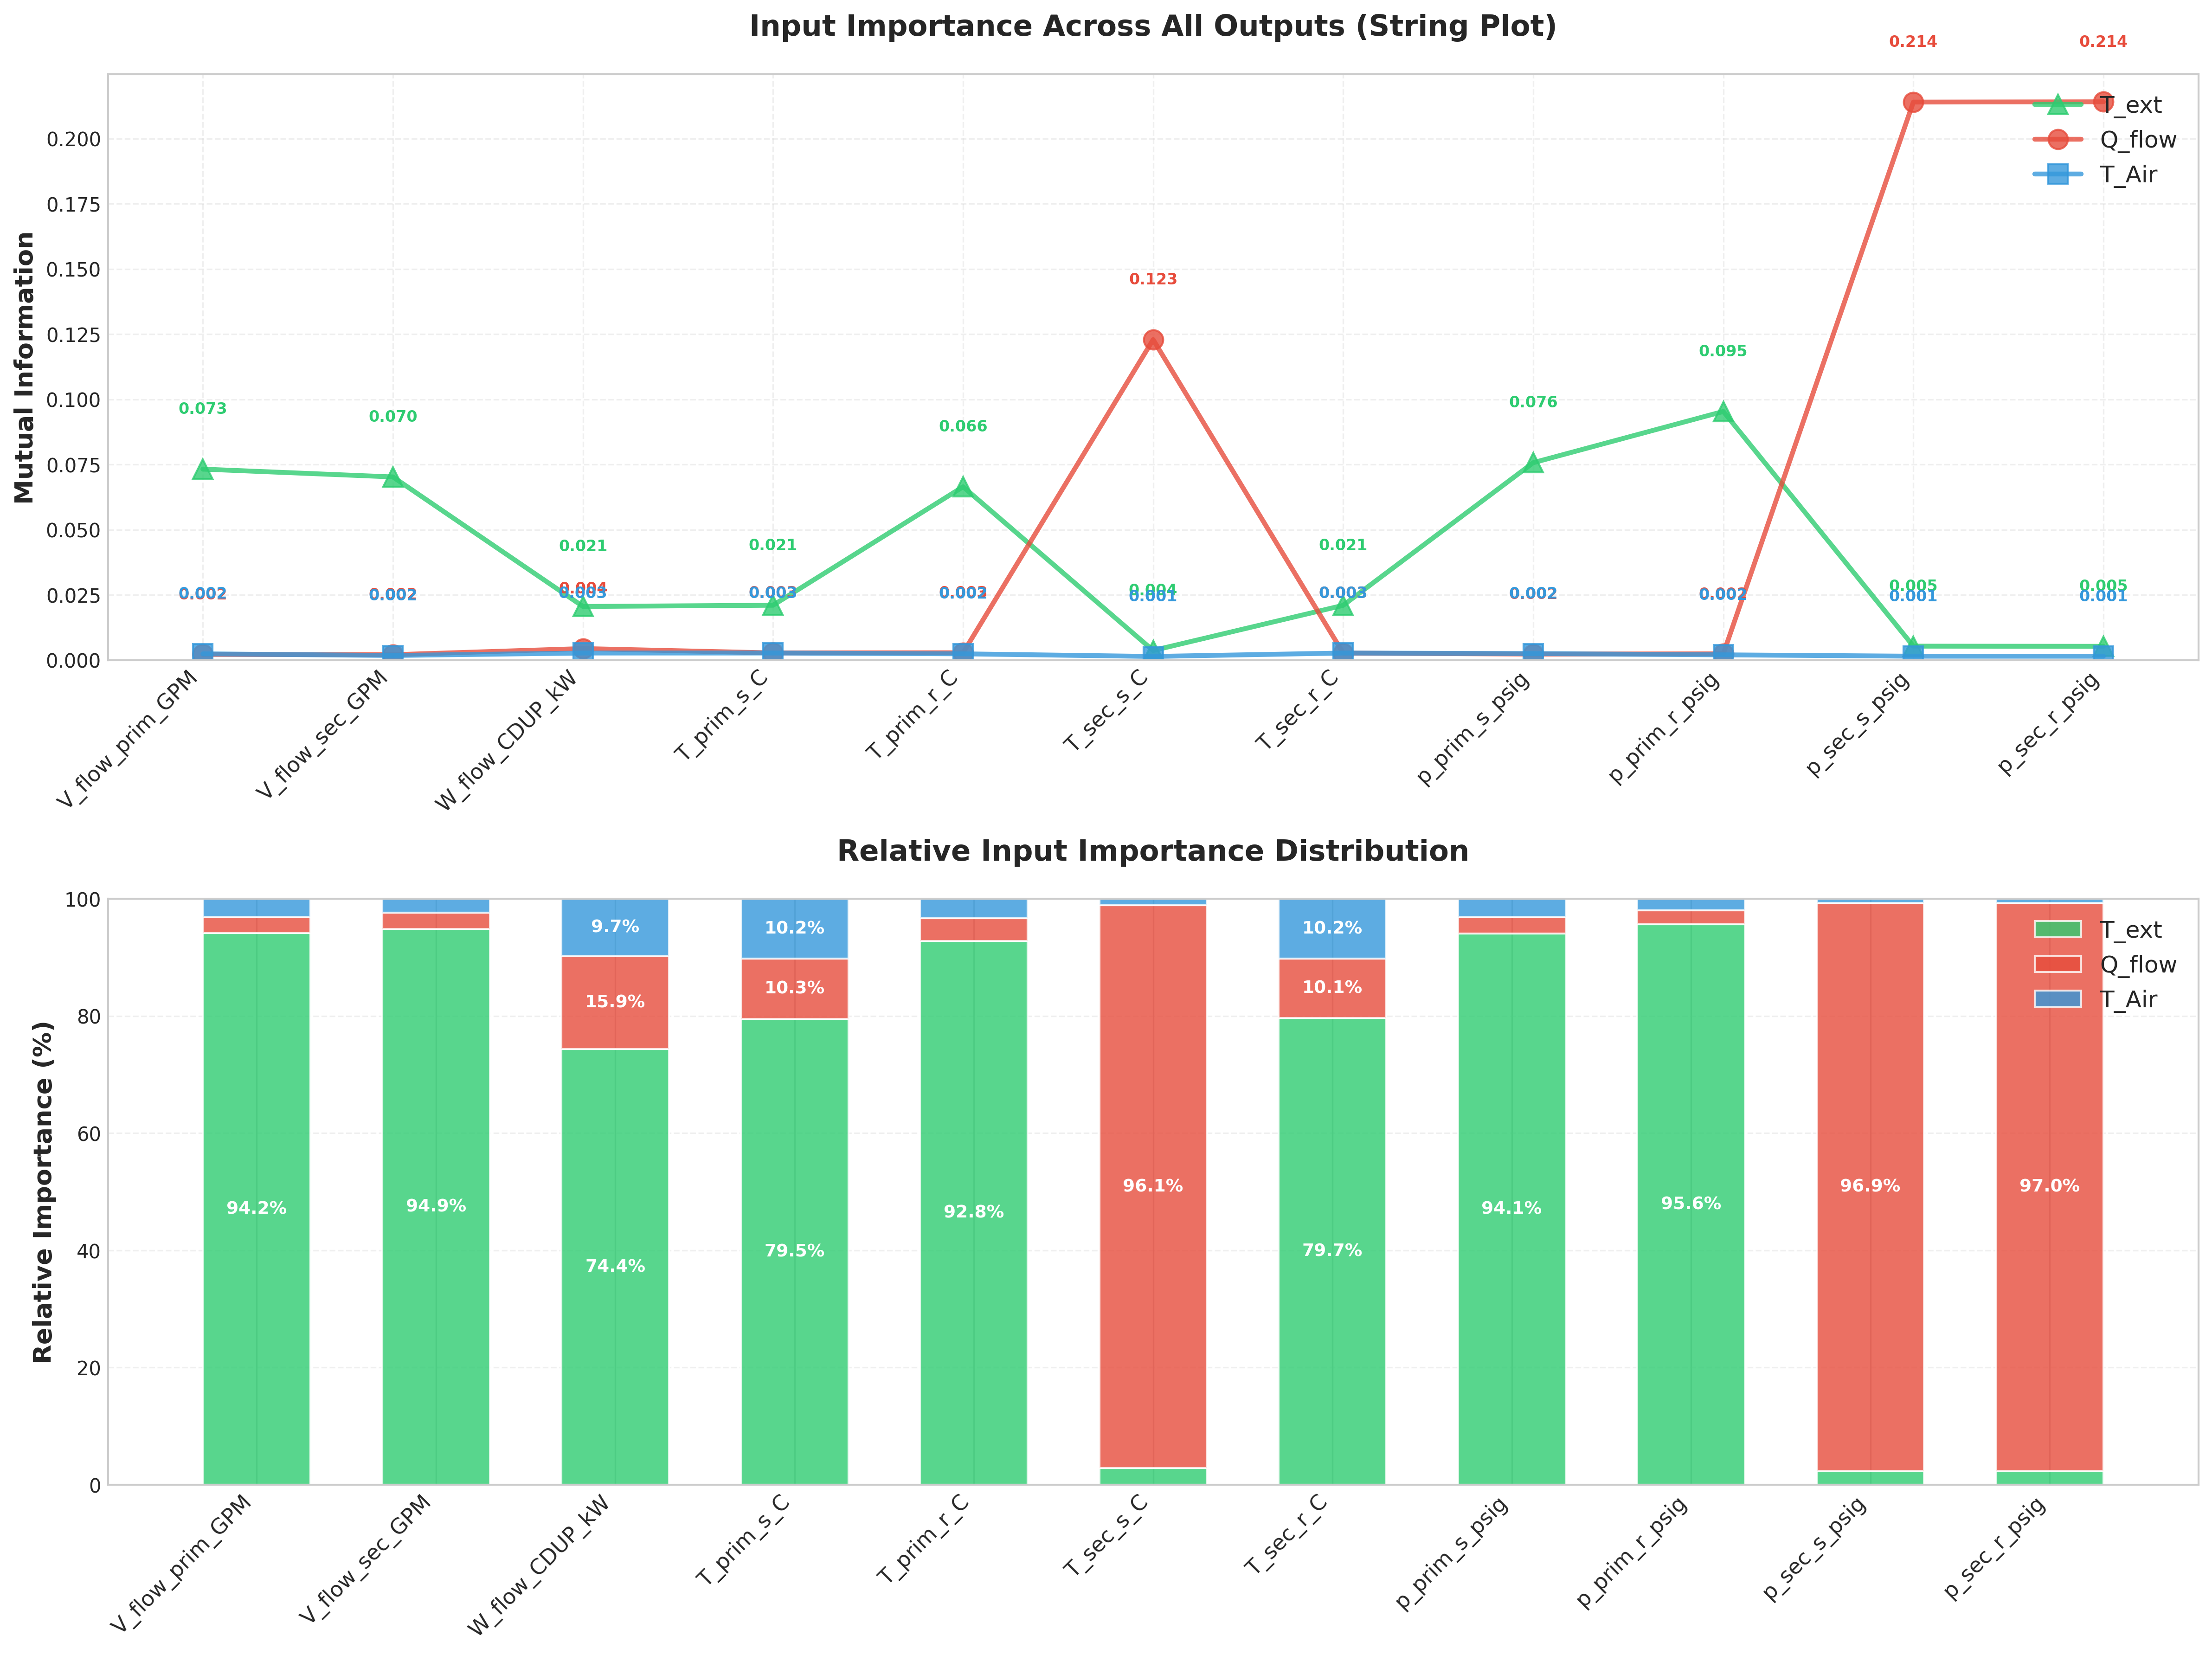

In [25]:
# Importance Ranking Plots
create_importance_ranking_plots(rankings_df, OUTPUT_DIR)
Image(filename=os.path.join(OUTPUT_DIR, 'importance_rankings.png'))


## Interaction Effects Analysis


In [26]:
# Interaction Effects Analysis
print("Analyzing interaction effects...")
interaction_df = analyzer.analyze_all_interaction_effects(prepared_data)


2026-02-03 08:28:06 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Analyzing interaction effects for all outputs in parallel...
2026-02-03 08:28:06 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Executing 11 interaction analysis tasks...


Analyzing interaction effects...


In [27]:
interaction_df

,output,r2_linear,r2_polynomial,interaction_effect
0,V_flow_prim_GPM,0.001162,0.003040,0.001878
1,V_flow_sec_GPM,0.524786,0.527352,0.002566
2,W_flow_CDUP_kW,0.007327,0.020105,0.012778
3,T_prim_s_C,0.081897,0.111460,0.029563
4,T_prim_r_C,0.006562,0.042015,0.035453
5,T_sec_s_C,0.007368,0.020107,0.012739
6,T_sec_r_C,0.008270,0.020913,0.012644
7,p_prim_s_psig,0.081428,0.127098,0.045670
8,p_prim_r_psig,0.019237,0.025117,0.005880
9,p_sec_s_psig,0.652000,0.667230,0.015230


## Response Surfaces Analysis

In [6]:
# Response Surfaces 
# key_outputs = ['T_sec_s_C','p_sec_s_psig','p_prim_r_psig']
# input_pairs = [('Q_flow', 'T_Air'), ('Q_flow', 'T_ext'), ('T_Air', 'T_ext')]
# Response Surfaces 
key_outputs = [
               # 'V_flow_prim_GPM','V_flow_sec_GPM','W_flow_CDUP_kW',
               # 'T_prim_s_C','T_prim_r_C',
               'T_sec_s_C','T_sec_r_C',
              'p_prim_s_psig','p_prim_r_psig',
               'p_sec_s_psig','p_sec_r_psig'
              ]
input_pairs = [('Q_flow', 'T_Air'), ('Q_flow', 'T_ext'), ('T_Air', 'T_ext')]

# Fixed inputs (middle of ranges) - already in correct units
fixed_inputs = {
    'Q_flow': (INPUT_RANGES['Q_flow'][0] + INPUT_RANGES['Q_flow'][1]) / 2 * 1000,  # W
    'T_Air': (INPUT_RANGES['T_Air'][0] + INPUT_RANGES['T_Air'][1]) / 2,  # K
    'T_ext': (INPUT_RANGES['T_ext'][0] + INPUT_RANGES['T_ext'][1]) / 2   # K
}

# Generate all response surface data
all_surface_data = {}
for input1, input2 in input_pairs:
    print(f"Generating surface data: {input1} x {input2}")
    
    # Remove varying inputs from fixed_inputs
    current_fixed = {k: v for k, v in fixed_inputs.items() 
                    if k not in (input1, input2)}
    
    # Pass ranges in kW/K - generate_response_surface_data() handles conversion
    surface_data = data_generator.generate_response_surface_data(
        input1=input1, 
        input2=input2,
        input1_range=INPUT_RANGES[input1],  # Pass in kW or K
        input2_range=INPUT_RANGES[input2],  # Pass in kW or K
        n_points_per_dim=30,
        fixed_inputs=current_fixed,  # Already in W and K
        stabilization_hours=0.4,  # stablization hour
        steady_state_steps=200,  # seconds of steady-state averaging
        n_workers=N_WORKERS,
        use_parallel=True
    )
    
    all_surface_data[(input1, input2)] = surface_data

# Compute response surfaces
surfaces = {}
for output in key_outputs:
    for input1, input2 in input_pairs:
        print(f"Computing surface: {output} vs {input1} x {input2}")
        
        surface_data = all_surface_data[(input1, input2)]
        
        # Prepare data for analysis
        surface_prepared = analyzer.prepare_data(surface_data)
        
        # Extract prepared data
        input1_data = surface_prepared['inputs'][input1]
        input2_data = surface_prepared['inputs'][input2]
        output_data = surface_prepared['outputs'][output]
        
        # Compute surface
        X, Y, Z = analyzer._compute_response_surface_static(
            input1_data, input2_data, output_data, n_points=30
        )
        
        surfaces[(output, input1, input2)] = (X, Y, Z)

# Create plots
create_response_surface_plots(surfaces, OUTPUT_DIR, n_workers=N_WORKERS)

Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...
Initializing FMU...


2026-02-04 11:43:07 - fmu2ml.analysis.input_output_relations.analyzers.data_generator - INFO - Successfully generated 900 response surface samples
2026-02-04 11:43:07 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Preparing data for direct effect analysis...
2026-02-04 11:43:07 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Data prepared: 3 inputs, 11 outputs
2026-02-04 11:43:07 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Preparing data for direct effect analysis...
2026-02-04 11:43:07 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Data prepared: 3 inputs, 11 outputs
2026-02-04 11:43:07 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Preparing data for direct effect analysis...
2026-02-04 11:43:07 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Data prepared: 3 inputs, 11 

Computing surface: T_sec_s_C vs Q_flow x T_Air
Computing surface: T_sec_s_C vs Q_flow x T_ext
Computing surface: T_sec_s_C vs T_Air x T_ext
Computing surface: T_sec_r_C vs Q_flow x T_Air
Computing surface: T_sec_r_C vs Q_flow x T_ext
Computing surface: T_sec_r_C vs T_Air x T_ext


2026-02-04 11:43:07 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Preparing data for direct effect analysis...
2026-02-04 11:43:07 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Data prepared: 3 inputs, 11 outputs
2026-02-04 11:43:07 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Preparing data for direct effect analysis...
2026-02-04 11:43:07 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Data prepared: 3 inputs, 11 outputs
2026-02-04 11:43:07 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Preparing data for direct effect analysis...
2026-02-04 11:43:07 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Data prepared: 3 inputs, 11 outputs
2026-02-04 11:43:07 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Preparing data for direct effect ana

Computing surface: p_prim_s_psig vs Q_flow x T_Air
Computing surface: p_prim_s_psig vs Q_flow x T_ext
Computing surface: p_prim_s_psig vs T_Air x T_ext
Computing surface: p_prim_r_psig vs Q_flow x T_Air
Computing surface: p_prim_r_psig vs Q_flow x T_ext
Computing surface: p_prim_r_psig vs T_Air x T_ext
Computing surface: p_sec_s_psig vs Q_flow x T_Air
Computing surface: p_sec_s_psig vs Q_flow x T_ext


2026-02-04 11:43:07 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Data prepared: 3 inputs, 11 outputs
2026-02-04 11:43:07 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Preparing data for direct effect analysis...
2026-02-04 11:43:07 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Data prepared: 3 inputs, 11 outputs
2026-02-04 11:43:07 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Preparing data for direct effect analysis...
2026-02-04 11:43:07 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Data prepared: 3 inputs, 11 outputs
2026-02-04 11:43:07 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Preparing data for direct effect analysis...
2026-02-04 11:43:07 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Data prepared: 3 inputs, 11 outputs


Computing surface: p_sec_s_psig vs T_Air x T_ext
Computing surface: p_sec_r_psig vs Q_flow x T_Air
Computing surface: p_sec_r_psig vs Q_flow x T_ext
Computing surface: p_sec_r_psig vs T_Air x T_ext


2026-02-04 11:43:09 - fmu2ml.analysis.input_output_relations.visualizers.surface_visualizer - INFO - Created 18/18 response surface plots


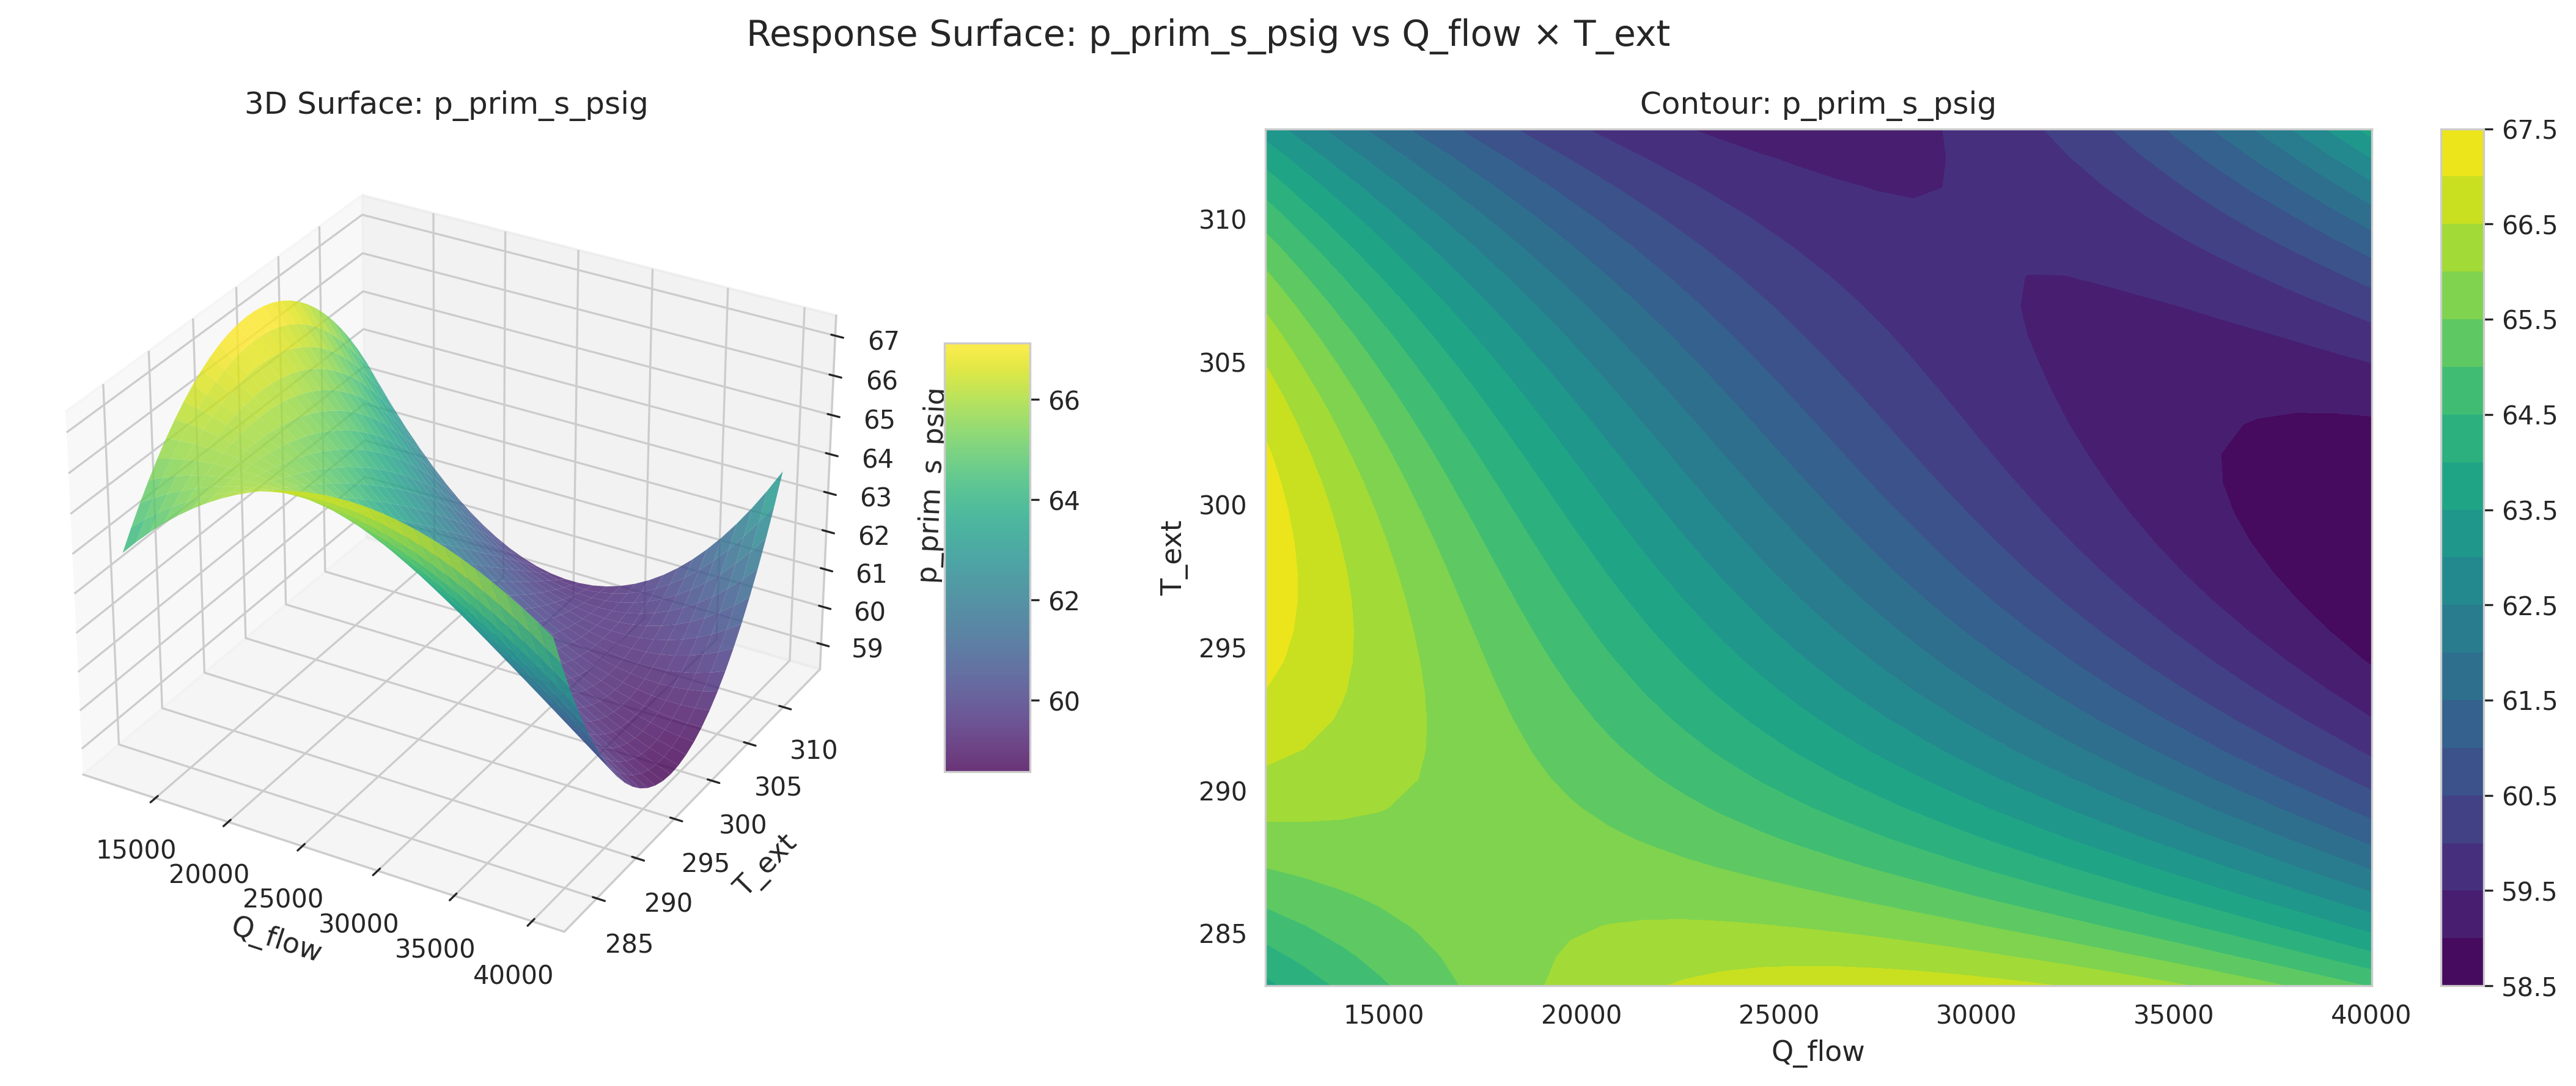

In [11]:
Image(filename=os.path.join(OUTPUT_DIR,'response_surface_p_prim_s_psig_Q_flow_T_ext.png'))


In [ ]:

# Slice Plots
create_slice_plots(
    prepared_data,
    output_vars=['T_prim_r_C'],
    input1='Q_flow',
    input2='T_ext',
    n_slices=10,
    output_dir=OUTPUT_DIR
)
Image(filename=os.path.join(OUTPUT_DIR, 'slice_plot_T_prim_r_C_Q_flow_vs_T_ext.png'))


## Summary Statistics


In [ ]:

# Summary Statistics
print("="*60)
print("ANALYSIS SUMMARY")
print("="*60)

print(f"\nTotal input-output pairs analyzed: {len(metrics_df)}")
print(f"Strong correlations (|r| > 0.7): {len(metrics_df[abs(metrics_df['pearson_r']) > 0.7])}")
print(f"High mutual information (> 0.5): {len(metrics_df[metrics_df['mutual_info'] > 0.5])}")
print(f"Good fits (R² > 0.8): {len(metrics_df[metrics_df['r2_score'] > 0.8])}")

print("\nTop 3 most important inputs overall:")
overall_importance = metrics_df.groupby('input')['mutual_info'].mean().sort_values(ascending=False)
print(overall_importance.head(3))


In [ ]:

# Save Results
metrics_df.to_csv(os.path.join(OUTPUT_DIR, 'sensitivity_metrics.csv'), index=False)
rankings_df.to_csv(os.path.join(OUTPUT_DIR, 'input_rankings.csv'), index=False)
interaction_df.to_csv(os.path.join(OUTPUT_DIR, 'interaction_effects.csv'), index=False)

print(f"\nResults saved to: {OUTPUT_DIR}")


In [ ]:

# Cleanup
analyzer._close_dask_client()
print("Analysis complete!")